<a href="https://colab.research.google.com/github/dipendragami230662-cpu/python-lab/blob/main/Copy_of_Linear_Regression_Mustafa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
 class MyLinearRegression:
    def __init__(self, weight=2, bias=4, learning_rate=0.0008,
                 iterations=855):
        self.weight = weight
        self.bias = bias
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.cost_trend = []
        self.cost = 0

    def predict(self, x):
        predicted_set = []
        for i in range(len(x)):
            predicted_value = self.weight * x[i][0] + self.bias # Access scalar value
            predicted_set.append(predicted_value)
        return predicted_set

    def cost_function(self, x, y):
        count = len(x)
        total_error = 0.0
        for i in range(count):
            total_error += (y[i] - (self.weight * x[i][0] + # Access scalar value
                            self.bias)) ** 2
        return total_error / (2 * count) # total_error should remain float if initialized as 0.0 and adding floats.

    def update_weights(self, x, y):
        weight_deriv = 0.0 # Initialize as float
        bias_deriv = 0.0   # Initialize as float
        count = len(x)

        for i in range(count):
            # Calculate partial derivatives
            # -2x(y - (mx + b))
            # Ensure x[i] is treated as a scalar
            x_scalar = x[i][0]
            error_term = (y[i] - (self.weight * x_scalar + self.bias))
            weight_deriv += -2 * x_scalar * error_term

            # -2(y - (mx + b))
            bias_deriv += -2 * error_term

        # We subtract because the derivatives point in direction of steepest
        # ascent
        self.weight -= (weight_deriv / count) * self.learning_rate
        self.bias -= (bias_deriv / count) * self.learning_rate

    def train(self, x, y):
        for i in range(self.iterations):
            self.update_weights(x, y)
            # Calculating cost
            self.cost = self.cost_function(x, y)
            self.cost_trend.append(self.cost)
            print(f"Iteration: {i}\t Weight: {self.weight}\t Bias: {self.bias}\t Cost: {self.cost}")

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# intialise data of lists.
data = {'Hours':[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8],
        'Scores':[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]}

# Create DataFrame
studentscores = pd.DataFrame(data)

# Print the output.
studentscores

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


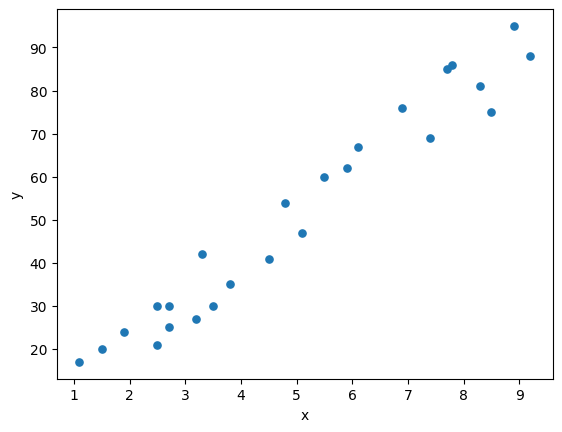

In [7]:
import matplotlib.pyplot as plt

x=[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8]
y=[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]
plt.scatter(x,y,s=27)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
# Predicting the Test set results
y_pred = regressor.predict(X_test)

# Simple comparison
print("COMPARISON OF PREDICTED VS ACTUAL VALUES:")
print("-" * 40)
for i in range(len(y_pred)):
    # Convert to float to avoid formatting issues
    pred_val = float(y_pred[i])
    actual_val = float(y_test[i])
    diff = abs(pred_val - actual_val)
    print(f"Predicted: {pred_val:.2f} | Actual: {actual_val:.2f} | Difference: {diff:.2f}")

# Calculate accuracy
errors = []
for i in range(len(y_pred)):
    error = abs(float(y_pred[i]) - float(y_test[i]))
    errors.append(error)

average_error = sum(errors) / len(errors)
print("-" * 40)
print(f"Average Error: {average_error:.2f}")
print(f"Best Prediction: {min(errors):.2f} off")
print(f"Worst Prediction: {max(errors):.2f} off")

In [14]:
#from my_linear_regression import MyLinearRegression
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Importing the dataset

X = studentscores.iloc[:, :-1].values
y = studentscores.iloc[:, -1].values
X,y

(array([[2.5],
        [5.1],
        [3.2],
        [8.5],
        [3.5],
        [1.5],
        [9.2],
        [5.5],
        [8.3],
        [2.7],
        [7.7],
        [5.9],
        [4.5],
        [3.3],
        [1.1],
        [8.9],
        [2.5],
        [1.9],
        [6.1],
        [7.4],
        [2.7],
        [4.8],
        [3.8],
        [6.9],
        [7.8]]),
 array([21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 30,
        24, 67, 69, 30, 54, 35, 76, 86]))

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)

# Fitting Simple Linear Regression to the Training set
regressor = MyLinearRegression()
regressor.train(X_train, y_train)
print('Weight: ' + str(regressor.weight) + ' Bias: ' + str(regressor.bias))

# Predicting the Test set results
y_pred = regressor.predict(X_test)

Iteration: 0	 Weight: 2.407476	 Bias: 4.06252	 Cost: 862.4445790328687
Iteration: 1	 Weight: 2.792167177128	 Bias: 4.12150087056	 Cost: 770.4257778140706
Iteration: 2	 Weight: 3.155347954231388	 Bias: 4.177140578192144	 Cost: 688.4128406502781
Iteration: 3	 Weight: 3.4982214717954196	 Bias: 4.229626016533323	 Cost: 615.3177538955578
Iteration: 4	 Weight: 3.8219235749834692	 Bias: 4.279133625684916	 Cost: 550.170811899379
Iteration: 5	 Weight: 4.127526577669942	 Bias: 4.32582997691096	 Cost: 492.10775247882844
Iteration: 6	 Weight: 4.416042815939326	 Bias: 4.369872324632368	 Cost: 440.3582912487359
Iteration: 7	 Weight: 4.688428002827191	 Bias: 4.411409127546428	 Cost: 394.23590270125374
Iteration: 8	 Weight: 4.945584395420273	 Bias: 4.450580540598493	 Cost: 353.1287124663427
Iteration: 9	 Weight: 5.188363784810975	 Bias: 4.4875188794361875	 Cost: 316.4913799260189
Iteration: 10	 Weight: 5.4175703188145885	 Bias: 4.522349058885285	 Cost: 283.8378634936654
Iteration: 11	 Weight: 5.633963

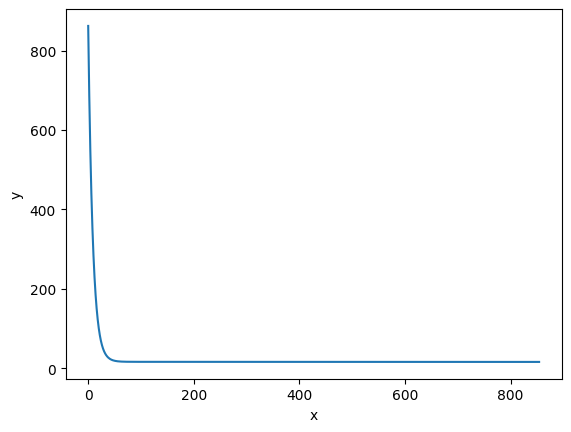

In [20]:
x=[i for i in range(len(regressor.cost_trend))]
y=regressor.cost_trend
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

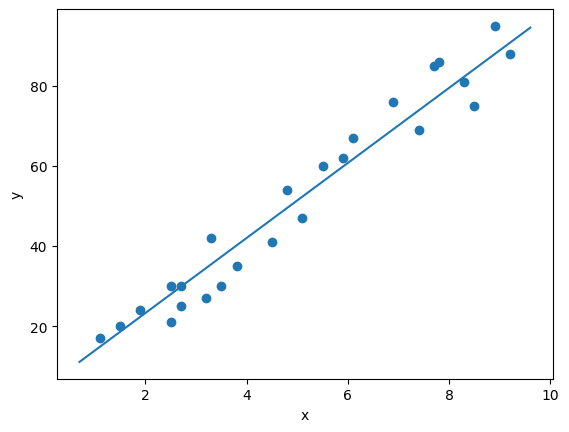

In [22]:
w = regressor.weight
b = regressor.bias
x=[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8]
y=[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]
plt.scatter(x,y)
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = b + w * x_vals
plt.plot(x_vals, y_vals)
plt.xlabel('x')
plt.ylabel('y')
plt.show()